# 🧠 AI CRM Brain — Sprint 2
## Phase 2: Data Preprocessing

---

> **Where we are:** Phase 1 (EDA) is done. We now understand the data.  
> **What we do here:** Transform raw data into a clean, numeric format that a Machine Learning model can actually use.

---

### Why do we need preprocessing?

ML models only understand **numbers**. Our data has:

| Column | Problem | Solution |
|---|---|---|
| `Stage` | Text (Won / Lost / ...) | Encode as numbers → **Label Encoding** |
| `Owner_Name` | Text, many unique names | Convert to numbers → **Frequency Encoding** |
| `Account_Name` | Text, many unique companies | Convert to numbers → **Frequency Encoding** |
| `Amount` | Numbers, but very wide range | Shrink to same scale → **StandardScaler** |
| `Closing_Date` | A date, not a number | Extract Year, Month, Quarter → **Feature Engineering** |
| `Deal_ID` | Just an ID, no signal | **Drop it** |

---

### Steps in this notebook

1. Reload & quick check
2. Feature Engineering (dates → numbers)
3. Drop columns we don't need
4. Encode categorical columns
5. Scale numerical columns
6. Train / Validation / Test split
7. Validate everything is clean
8. Save the preprocessing pipeline
9. Final summary

---


## Step 1 — Setup & Reload Data

We import the same libraries as Phase 1, plus a few new ones for preprocessing.  
Then we reload the raw data exactly as it came from Zoho / PostgreSQL.


In [1]:
# ── Imports ───────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import json
import pickle
from pathlib import Path

# New imports for preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import LabelEncoder, StandardScaler
from sklearn.pipeline        import Pipeline

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white'})

# Stage colour map — same as Phase 1
STAGE_COLOURS = {
    'Won': '#16A34A', 'Lost': '#DC2626',
    'Engaging': '#2563EB', 'Prospecting': '#D97706',
}

# Output folder for saved artefacts (encoders, scalers, split data)
ARTEFACTS_DIR = Path('preprocessing')
ARTEFACTS_DIR.mkdir(exist_ok=True)

print("✅ All imports successful.")
print(f"   Artefacts will be saved to: {ARTEFACTS_DIR.resolve()}")


✅ All imports successful.
   Artefacts will be saved to: /mnt/d/01_Projects/NLP/AI CRM Brain/AI-CRM-Brain/notebooks/preprocessing


In [2]:
# ── Reload data ───────────────────────────────────────────────
# Option A: from CSV — update the filename if needed
df = pd.read_csv('/mnt/d/01_Projects/NLP/AI CRM Brain/AI-CRM-Brain/data/sales_cleaned/cleaned_sales_pipeline.csv')

# Option B: from PostgreSQL — uncomment below and comment out Option A
# from sqlalchemy import create_engine
# from dotenv import load_dotenv
# load_dotenv()
# engine = create_engine(
#     f"postgresql+psycopg2://{os.getenv('POSTGRES_USER')}:{os.getenv('POSTGRES_PASSWORD')}"
#     f"@{os.getenv('POSTGRES_HOST','localhost')}:5432/{os.getenv('POSTGRES_DB')}"
# )
# df = pd.read_sql("SELECT * FROM zoho_deals;", con=engine)

# Parse the date column
df['Closing_Date'] = pd.to_datetime(df['Closing_Date'])

print(f"✅ Data loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print()
print(df.head(3))


✅ Data loaded: 8,800 rows × 12 columns

        Owner_Name Account_Name Stage Closing_Date  Amount  Close_Month  \
0      Moses Frase      Cancity   Won   2017-03-01  1054.0          3.0   
1  Darcel Schlecht        Isdom   Won   2017-03-11  4514.0          3.0   
2  Darcel Schlecht      Cancity   Won   2017-03-07    50.0          3.0   

   Close_Year    Year  Month Month_Name Day_of_Week Quarter  
0      2017.0  2017.0    3.0        Mar   Wednesday      Q1  
1      2017.0  2017.0    3.0        Mar    Saturday      Q1  
2      2017.0  2017.0    3.0        Mar     Tuesday      Q1  


---
## Step 2 — Feature Engineering (Dates → Numbers)

`Closing_Date` is a date. We can't feed a date directly into a model.  
Instead, we **extract useful numeric features** from it:

| New Feature | What it captures |
|---|---|
| `Close_Year` | Which year the deal closes |
| `Close_Month` | Which month (1–12) — captures seasonality |
| `Close_Quarter` | Q1 / Q2 / Q3 / Q4 — another seasonality signal |
| `Close_DayOfWeek` | 0=Monday ... 6=Sunday |
| `Deal_Age_Days` | Days between deal creation and closing date |

> **Tip:** More features = more signal for the model.  
> We can always remove a feature later if it turns out not to be useful.


In [3]:
# Extract date-based features
df['Close_Year']      = df['Closing_Date'].dt.year
df['Close_Month']     = df['Closing_Date'].dt.month
df['Close_Quarter']   = df['Closing_Date'].dt.quarter
df['Close_DayOfWeek'] = df['Closing_Date'].dt.dayofweek  # 0=Mon, 6=Sun

# Deal Age: how many days from the start of the dataset to this deal's closing date
# (A proxy for "how long has this deal been in the pipeline")
reference_date      = df['Closing_Date'].min()
df['Deal_Age_Days'] = (df['Closing_Date'] - reference_date).dt.days

print("✅ Date features extracted:")
print()
display(df[['Closing_Date','Close_Year','Close_Month',
            'Close_Quarter','Close_DayOfWeek','Deal_Age_Days']].head(8))


✅ Date features extracted:



,Closing_Date,Close_Year,Close_Month,Close_Quarter,Close_DayOfWeek,Deal_Age_Days
0,2017-03-01,2017.0,3.0,1.0,2.0,0.0
1,2017-03-11,2017.0,3.0,1.0,5.0,10.0
2,2017-03-07,2017.0,3.0,1.0,1.0,6.0
3,2017-03-09,2017.0,3.0,1.0,3.0,8.0
4,2017-03-02,2017.0,3.0,1.0,3.0,1.0
5,2017-03-01,2017.0,3.0,1.0,2.0,0.0
6,2017-03-02,2017.0,3.0,1.0,3.0,1.0
7,2017-03-07,2017.0,3.0,1.0,1.0,6.0


── Date Feature Ranges ───────────────────────────────────────
  Close_Year      : 2017.0 → 2017.0
  Close_Month     : 3.0 → 12.0
  Close_Quarter   : 1.0 → 4.0
  Close_DayOfWeek : 0.0 → 6.0
  Deal_Age_Days   : 0.0 → 305.0


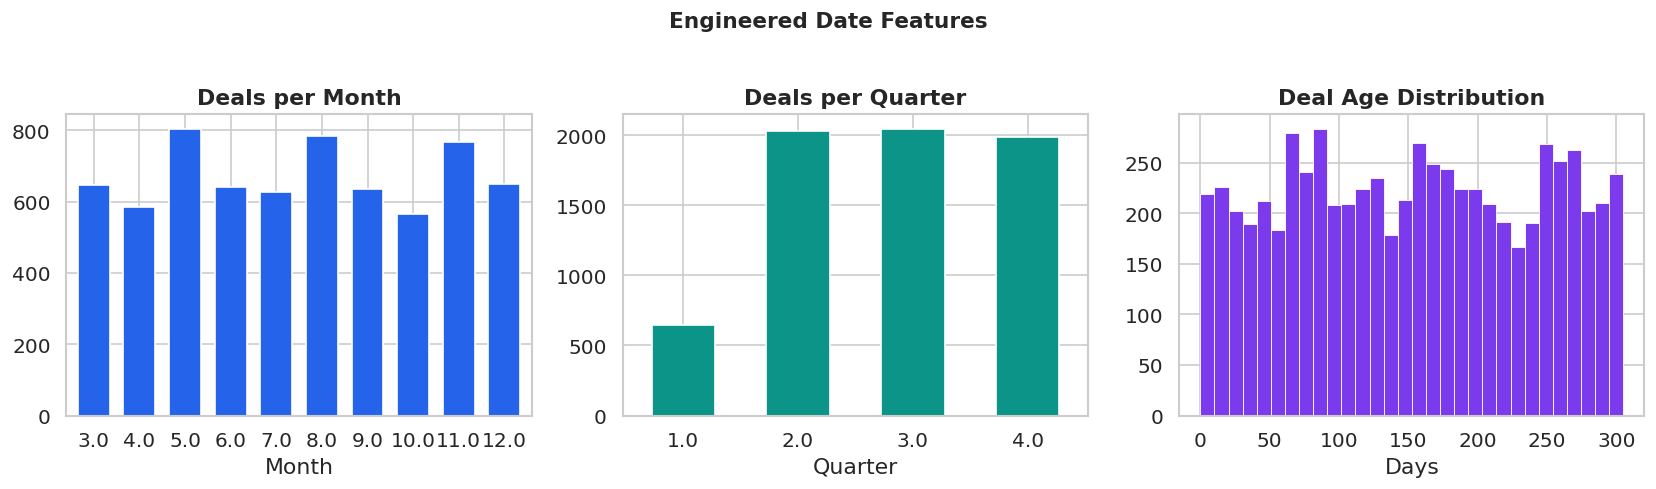

✅ Chart saved as 'engineered_features.png'


In [4]:
# Quick check — are these features sensible?
print("── Date Feature Ranges ───────────────────────────────────────")
print(f"  Close_Year      : {df['Close_Year'].min()} → {df['Close_Year'].max()}")
print(f"  Close_Month     : {df['Close_Month'].min()} → {df['Close_Month'].max()}")
print(f"  Close_Quarter   : {df['Close_Quarter'].min()} → {df['Close_Quarter'].max()}")
print(f"  Close_DayOfWeek : {df['Close_DayOfWeek'].min()} → {df['Close_DayOfWeek'].max()}")
print(f"  Deal_Age_Days   : {df['Deal_Age_Days'].min()} → {df['Deal_Age_Days'].max()}")

# Visualise the new features quickly
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

df['Close_Month'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='#2563EB', edgecolor='white', width=0.7)
axes[0].set_title('Deals per Month', fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].tick_params(axis='x', rotation=0)

df['Close_Quarter'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color='#0D9488', edgecolor='white', width=0.55)
axes[1].set_title('Deals per Quarter', fontweight='bold')
axes[1].set_xlabel('Quarter')
axes[1].tick_params(axis='x', rotation=0)

axes[2].hist(df['Deal_Age_Days'], bins=30,
             color='#7C3AED', edgecolor='white', linewidth=0.5)
axes[2].set_title('Deal Age Distribution', fontweight='bold')
axes[2].set_xlabel('Days')

plt.suptitle('Engineered Date Features', fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('engineered_features.png', bbox_inches='tight')
plt.show()
print("✅ Chart saved as 'engineered_features.png'")


---
## Step 3 — Drop Columns We Don't Need

Some columns carry **no useful signal** for predicting deal stage:

- `Deal_ID` → just a random ID string. Every deal has a unique one — it tells the model nothing about whether a deal will be Won or Lost.
- `Closing_Date` → we already extracted everything useful from it in Step 2.

We keep all other columns for now.


In [5]:
df.columns

Index(['Owner_Name', 'Account_Name', 'Stage', 'Closing_Date', 'Amount',
       'Close_Month', 'Close_Year', 'Year', 'Month', 'Month_Name',
       'Day_of_Week', 'Quarter', 'Close_Quarter', 'Close_DayOfWeek',
       'Deal_Age_Days'],
      dtype='object')

In [7]:
# Define what to drop
COLS_TO_DROP = ['Closing_Date','Month','Year','Quarter','Day_of_Week','Month_Name']

df_clean = df.drop(columns=COLS_TO_DROP)

print(f"✅ Dropped columns: {COLS_TO_DROP}")
print(f"   Before: {df.shape[1]} columns")
print(f"   After : {df_clean.shape[1]} columns")
print()
print("Remaining columns:")
for col in df_clean.columns:
    dtype = str(df_clean[col].dtype)
    print(f"   {col:<20}  {dtype}")


✅ Dropped columns: ['Closing_Date', 'Month', 'Year', 'Quarter', 'Day_of_Week', 'Month_Name']
   Before: 15 columns
   After : 9 columns

Remaining columns:
   Owner_Name            object
   Account_Name          object
   Stage                 object
   Amount                float64
   Close_Month           float64
   Close_Year            float64
   Close_Quarter         float64
   Close_DayOfWeek       float64
   Deal_Age_Days         float64


## Split the Data into train, test, valid before apply preprocessing

In [8]:
# 1. Define Features (X) and Target (y)
# Drop 'Stage' because it's what we want to predict.
X = df_clean.drop(columns=['Stage'], errors='ignore')
y = df_clean['Stage']


In [9]:
X.shape, y.shape

((8800, 8), (8800,))

In [10]:
X.columns

Index(['Owner_Name', 'Account_Name', 'Amount', 'Close_Month', 'Close_Year',
       'Close_Quarter', 'Close_DayOfWeek', 'Deal_Age_Days'],
      dtype='object')

In [13]:
y.value_counts()

Stage
Won            4238
Lost           2473
Engaging       1589
Prospecting     500
Name: count, dtype: int64

In [26]:

# 2. First Split: Separate out the Test Set (15%)
# This leaves 85% of the data for the temporary training pool
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, 
    test_size=0.15, 
    random_state=42, 
    stratify=y
)

# 3. Second Split: Divide the temporary pool into Train and Validation
# We want Validation to be 15% of the ORIGINAL data.
# Since X_temp is 85% of the original, 15 / 85 = 0.1764 (approx 17.6%)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, 
    test_size=(0.15 / 0.85), 
    random_state=42, 
    stratify=y_temp
)

# 4. Verify the sizes
print(f"Total dataset size: {len(df)} deals")
print(f"Training set:       {len(X_train)} deals ({len(X_train)/len(df)*100:.1f}%)")
print(f"Validation set:     {len(X_val)} deals ({len(X_val)/len(df)*100:.1f}%)")
print(f"Test set:           {len(X_test)} deals ({len(X_test)/len(df)*100:.1f}%)")

Total dataset size: 8800 deals
Training set:       6160 deals (70.0%)
Validation set:     1320 deals (15.0%)
Test set:           1320 deals (15.0%)


In [27]:
X_train.shape, y_train.shape, X_val.shape, y_val.shape, X_test.shape, y_test.shape

((6160, 8), (6160,), (1320, 8), (1320,), (1320, 8), (1320,))

---
## Step 4 — Encode the Target Column (Stage)

The `Stage` column is our **target** — what we want to predict.  
We must convert text labels into numbers.

We use **Label Encoding**:

| Stage | Encoded Number |
|---|---|
| Engaging | 0 |
| Lost | 1 |
| Prospecting | 2 |
| Won | 3 |

> **Important:** We save the encoder so we can reverse this later  
> (to show the user "Won" instead of "3" in the dashboard).


In [28]:
# Encode Stage (our target variable)
label_enc = LabelEncoder()

y_train_encoded = label_enc.fit_transform(y_train)
y_test_encoded  = label_enc.transform(y_test)
y_val_encoded   = label_enc.transform(y_val)


In [31]:
y_train_encoded

array([1, 3, 3, ..., 3, 0, 3])

In [32]:
stage_mapping = dict(zip(label_enc.classes_, label_enc.transform(label_enc.classes_)))
print(f"Stage to Number Mapping: {stage_mapping}")

Stage to Number Mapping: {'Engaging': 0, 'Lost': 1, 'Prospecting': 2, 'Won': 3}


In [ ]:
# Save the LabelEncoder so we can decode predictions later
le_path = ARTEFACTS_DIR / 'label_encoder_stage.pkl'
with open(le_path, 'wb') as f:
    pickle.dump(label_enc, f)

print(f" LabelEncoder saved to: {le_path}")
print()
print("   To reload it later:")
print("   with open('preprocessing_artefacts/label_encoder_stage.pkl', 'rb') as f:")
print("       label_enc = pickle.load(f)")


✅ LabelEncoder saved to: preprocessing/label_encoder_stage.pkl

   To reload it later:
   with open('preprocessing_artefacts/label_encoder_stage.pkl', 'rb') as f:
       label_enc = pickle.load(f)


---
## Step 5 — Encode Categorical Columns

We have two more text columns: `Owner_Name` and `Account_Name`.

### Which encoding should we use?

| Column | Unique Values | Strategy | Why |
|---|---|---|---|
| `Owner_Name` | ~Few owners | **Frequency Encoding** | Replaces each name with how often it appears |
| `Account_Name` | ~Many companies | **Frequency Encoding** | High cardinality — OHE would create too many columns |

### What is Frequency Encoding?

It replaces each category with the **number of times it appears** in the dataset.

Example:
```
Moses Frase   → appeared 120 times → 120
Darcel Schlecht → appeared 85 times → 85
```

> **Why not OneHotEncoding here?**  
> If `Account_Name` has 200 unique values, OHE would create 200 new columns —  
> most of them mostly zeros. Frequency encoding gives one compact column instead.


In [43]:
# ── Frequency Encoding for Owner_Name ────────────────────────────
owner_freq = X_train['Owner_Name'].value_counts().to_dict()
X_train['Owner_Freq'] = X_train['Owner_Name'].map(owner_freq)

print("Owner_Name → Owner_Freq (frequency encoding)")
print()
print("── Top 10 Owner Frequencies ──────────────────────────────────")
top_owners = pd.DataFrame({
    'Owner_Name' : list(owner_freq.keys())[:10],
    'Frequency'  : list(owner_freq.values())[:10],
}).sort_values('Frequency', ascending=False)
display(top_owners)


Owner_Name → Owner_Freq (frequency encoding)

── Top 10 Owner Frequencies ──────────────────────────────────


,Owner_Name,Frequency
0,Darcel Schlecht,516
1,Vicki Laflamme,325
2,Anna Snelling,309
3,Kary Hendrixson,297
4,Jonathan Berthelot,256
5,Kami Bicknell,253
6,Cassey Cress,253
7,Zane Levy,252
8,Versie Hillebrand,246
9,Markita Hansen,218


In [83]:
mapping = dict(zip(label_enc.classes_,
                   label_enc.transform(label_enc.classes_)))

In [44]:
# ── Frequency Encoding for Account_Name ──────────────────────────
account_freq = X_train['Account_Name'].value_counts().to_dict()
X_train['Account_Freq'] = X_train['Account_Name'].map(account_freq)

print(" Account_Name → Account_Freq (frequency encoding)")
print()
print(f"   Unique accounts encoded: {len(account_freq):,}")
print()
print(X_train[['Account_Name','Account_Freq']].drop_duplicates().head(8))


 Account_Name → Account_Freq (frequency encoding)

   Unique accounts encoded: 86

            Account_Name  Account_Freq
2201           Konmatfix            56
3317          Bioholding            65
4906  Globex Corporation            73
9                Unknown          1001
2660       Y-corporation            65
8609             Codehow            76
6525           Treequote            85
8060             Cancity            70


In [45]:
# Save frequency maps so we can apply them to new data during inference
freq_maps = {
    'owner_freq'  : owner_freq,
    'account_freq': account_freq,
}

freq_path = ARTEFACTS_DIR / 'frequency_maps.json'
with open(freq_path, 'w') as f:
    json.dump(freq_maps, f, indent=2)

print(f" Frequency maps saved to: {freq_path}")
print()




 Frequency maps saved to: preprocessing/frequency_maps.json



In [46]:
# Verify encoding worked — no nulls after mapping
null_check = df_clean[['Owner_Freq','Account_Freq']].isna().sum()
if null_check.sum() == 0:
    print(" No nulls after encoding — all values mapped correctly.")
else:
    print(f"⚠️  Nulls after encoding: {null_check.to_dict()}")
    print("   This means some values were not in the frequency map.")

 No nulls after encoding — all values mapped correctly.


In [47]:
# apply the frequency encoding to our train/val/test splits
def apply_frequency_encoding(X, owner_freq, account_freq):
    X = X.copy()
    X['Owner_Freq']   = X['Owner_Name'].map(owner_freq)
    X['Account_Freq'] = X['Account_Name'].map(account_freq)
    return X



In [48]:
X_train_encoded = apply_frequency_encoding(X_train, owner_freq, account_freq)
X_val_encoded   = apply_frequency_encoding(X_val, owner_freq, account_freq)
X_test_encoded  = apply_frequency_encoding(X_test, owner_freq, account_freq)


In [49]:
# Check the new encoded features in the training set
print("Sample of encoded features in the training set:")
display(X_train_encoded[['Owner_Name','Owner_Freq','Account_Name','Account_Freq']].head(8))

Sample of encoded features in the training set:


,Owner_Name,Owner_Freq,Account_Name,Account_Freq
2201,Versie Hillebrand,246,Konmatfix,56
3317,Anna Snelling,309,Bioholding,65
4906,Marty Freudenburg,190,Globex Corporation,73
9,James Ascencio,186,Unknown,1001
2660,Rosalina Dieter,100,Y-corporation,65
7965,Darcel Schlecht,516,Konmatfix,56
8609,Lajuana Vencill,209,Codehow,76
6525,Anna Snelling,309,Treequote,85


In [51]:
X_train.isnull().sum(), X_val.isnull().sum(), X_test.isnull().sum()

(Owner_Name            0
 Account_Name          0
 Amount                0
 Close_Month        1463
 Close_Year         1463
 Close_Quarter      1463
 Close_DayOfWeek    1463
 Deal_Age_Days      1463
 Owner_Freq            0
 Account_Freq          0
 dtype: int64,
 Owner_Name           0
 Account_Name         0
 Amount               0
 Close_Month        313
 Close_Year         313
 Close_Quarter      313
 Close_DayOfWeek    313
 Deal_Age_Days      313
 dtype: int64,
 Owner_Name           0
 Account_Name         0
 Amount               0
 Close_Month        313
 Close_Year         313
 Close_Quarter      313
 Close_DayOfWeek    313
 Deal_Age_Days      313
 dtype: int64)

In [52]:
X_train_encoded.isnull().sum(), X_val_encoded.isnull().sum(), X_test_encoded.isnull().sum()

(Owner_Name            0
 Account_Name          0
 Amount                0
 Close_Month        1463
 Close_Year         1463
 Close_Quarter      1463
 Close_DayOfWeek    1463
 Deal_Age_Days      1463
 Owner_Freq            0
 Account_Freq          0
 dtype: int64,
 Owner_Name           0
 Account_Name         0
 Amount               0
 Close_Month        313
 Close_Year         313
 Close_Quarter      313
 Close_DayOfWeek    313
 Deal_Age_Days      313
 Owner_Freq           0
 Account_Freq         0
 dtype: int64,
 Owner_Name           0
 Account_Name         0
 Amount               0
 Close_Month        313
 Close_Year         313
 Close_Quarter      313
 Close_DayOfWeek    313
 Deal_Age_Days      313
 Owner_Freq           0
 Account_Freq         0
 dtype: int64)

In [53]:
# List of columns that have missing date-related values
date_features = [
    'Close_Month', 'Close_Year', 'Close_Quarter', 
    'Close_DayOfWeek', 'Deal_Age_Days'
]

# Impute all missing values in these columns with -1
for col in date_features:
    # Only fill if the column actually exists in the dataframe
    if col in X_train_encoded.columns:
        X_train_encoded[col] = X_train_encoded[col].fillna(-1)
        X_val_encoded[col]   = X_val_encoded[col].fillna(-1)
        X_test_encoded[col]  = X_test_encoded[col].fillna(-1)

# Verify that all nulls are gone
print("Nulls remaining in X_train:")
print(X_train_encoded.isna().sum())

Nulls remaining in X_train:
Owner_Name         0
Account_Name       0
Amount             0
Close_Month        0
Close_Year         0
Close_Quarter      0
Close_DayOfWeek    0
Deal_Age_Days      0
Owner_Freq         0
Account_Freq       0
dtype: int64


In [61]:
X_train_encoded.dtypes

Owner_Name          object
Account_Name        object
Amount             float64
Close_Month        float64
Close_Year         float64
Close_Quarter      float64
Close_DayOfWeek    float64
Deal_Age_Days      float64
Owner_Freq           int64
Account_Freq         int64
dtype: object

In [62]:
# Drop unnecessary columns that won't be used for modeling
cols_to_drop = ['Owner_Name', 'Account_Name']
X_train_encoded = X_train_encoded.drop(columns=cols_to_drop, errors='ignore')
X_val_encoded   = X_val_encoded.drop(columns=cols_to_drop, errors='ignore')
X_test_encoded  = X_test_encoded.drop(columns=cols_to_drop, errors='ignore')

---
## Step 6 — Scale Numerical Columns

Our numerical features have **very different ranges**:

| Feature | Range (approx) |
|---|---|
| `Amount` | $50 → $50,000+ |
| `Close_Month` | 1 → 12 |
| `Deal_Age_Days` | 0 → 1,000+ |

Without scaling, the model might think `Amount` is more important just because  
its numbers are bigger. We use **StandardScaler** to fix this.

### What does StandardScaler do?

It transforms each feature so that:
- **Mean = 0**
- **Standard deviation = 1**

Every feature ends up on the same scale. The model can then compare them fairly.

> ⚠️ **Critical rule:** We fit the scaler **only on training data**.  
> We then apply it to validation and test data.  
> Fitting on all data would cause **data leakage** (cheating).


In [ ]:
# These are all the numerical columns we will scale
NUMERICAL_FEATURES = [
    'Amount',
    'Close_Year',
    'Close_Month',
    'Close_Quarter',
    'Close_DayOfWeek',
    'Deal_Age_Days',
    'Owner_Freq',
    'Account_Freq',
]




---
## Step 7 — Build the Final Feature Matrix (X and y)

Before splitting, we define:
- **X** → the input features (everything the model learns from)
- **y** → the target (what the model predicts: Stage)


---
## Step 8 — Split into Train / Validation / Test Sets

We split the data into **three separate sets**:

| Set | Size | Purpose |
|---|---|---|
| **Train** | 70% | The model learns from this |
| **Validation** | 15% | We tune and compare models using this |
| **Test** | 15% | Final evaluation — touched only once, at the very end |

### Why three sets and not two?

Using only train/test means we'd keep peeking at the test set while tuning —  
which makes the test score optimistic. The validation set gives us  
an honest evaluation during development.

### What is stratified splitting?

We use `stratify=y` to ensure each split has the **same proportion** of  
Won/Lost/Engaging/Prospecting as the full dataset.  
Without this, we might accidentally put all "Prospecting" deals in the test set.


In [56]:
# Verify class proportions are preserved in each split
def class_proportions(y_series, label_encoder):
    """Shows class proportions for a target series."""
    counts = pd.Series(y_series).value_counts().sort_index()
    pcts   = (counts / len(y_series) * 100).round(1)
    names  = label_encoder.inverse_transform(counts.index)
    return pd.DataFrame({'Class': names, 'Count': counts.values, '%': pcts.values})

print("── Class proportions per split ───────────────────────────────")
print()
print("  TRAIN")
display(class_proportions(y_train_encoded, label_enc))
print()
print("  VALIDATION")
display(class_proportions(y_val_encoded, label_enc))
print()
print("  TEST")
display(class_proportions(y_test_encoded, label_enc))


── Class proportions per split ───────────────────────────────

  TRAIN


,Class,Count,%
0,Engaging,1113,18.1
1,Lost,1731,28.1
2,Prospecting,350,5.7
3,Won,2966,48.1



  VALIDATION


,Class,Count,%
0,Engaging,238,18.0
1,Lost,371,28.1
2,Prospecting,75,5.7
3,Won,636,48.2



  TEST


,Class,Count,%
0,Engaging,238,18.0
1,Lost,371,28.1
2,Prospecting,75,5.7
3,Won,636,48.2


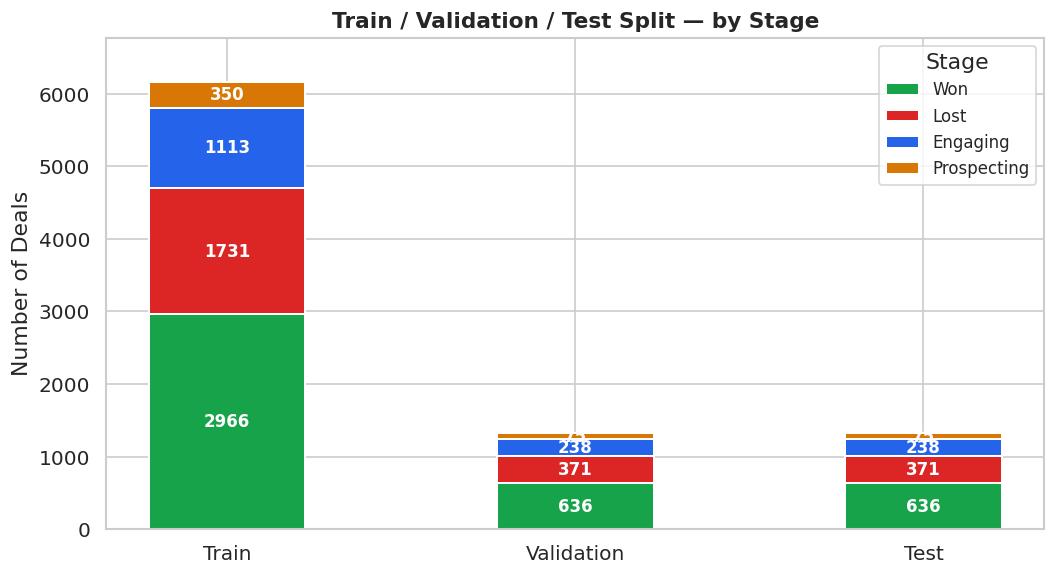

✅ Chart saved as 'train_val_test_split.png'


In [57]:
# Visualise the split — stacked bar showing each stage in each set
split_data = {}
for name, y_part in [('Train', y_train_encoded), ('Validation', y_val_encoded), ('Test', y_test_encoded)]:
    counts = pd.Series(y_part).value_counts().sort_index()
    split_data[name] = {label_enc.inverse_transform([i])[0]: v
                        for i, v in counts.items()}

split_df = pd.DataFrame(split_data).T
stage_order = [s for s in ['Won','Lost','Engaging','Prospecting']
               if s in split_df.columns]
split_df = split_df[stage_order]

fig, ax = plt.subplots(figsize=(9, 5))
left = np.zeros(len(split_df))

for stage in stage_order:
    vals = split_df[stage].values
    bars = ax.bar(split_df.index, vals, bottom=left,
                  color=STAGE_COLOURS.get(stage,'#94A3B8'),
                  edgecolor='white', linewidth=1.2, label=stage, width=0.45)
    for bar, v, l in zip(bars, vals, left):
        if v > 20:
            ax.text(bar.get_x() + bar.get_width()/2, l + v/2,
                    str(int(v)), ha='center', va='center',
                    fontsize=10, color='white', fontweight='bold')
    left = left + vals

ax.set_title('Train / Validation / Test Split — by Stage',
             fontweight='bold', fontsize=13)
ax.set_ylabel('Number of Deals')
ax.legend(title='Stage', fontsize=10)
ax.set_ylim(0, left.max() * 1.1)

plt.tight_layout()
plt.savefig('train_val_test_split.png', bbox_inches='tight')
plt.show()
print("✅ Chart saved as 'train_val_test_split.png'")


---
## Step 9 — Fit and Apply the Scaler

Now we fit `StandardScaler` **on the training set only**, then apply it  
to train, validation, and test sets.

> **Why fit only on train?**  
> Fitting on all data would let information from validation/test  
> "leak" into the scaler, making our results falsely optimistic.


In [63]:
# Fit scaler on TRAINING SET ONLY
scaler = StandardScaler()
scaler.fit(X_train_encoded)   # ← learns mean and std from train data only




StandardScaler()

In [65]:
# Apply scaler to all three sets
X_train_scaled = scaler.transform(X_train_encoded)
X_val_scaled   = scaler.transform(X_val_encoded)
X_test_scaled  = scaler.transform(X_test_encoded)




In [74]:
# Convert the numpy arrays back to DataFrames for easier handling later
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train_encoded.columns, index=X_train_encoded.index)
X_val_scaled   = pd.DataFrame(X_val_scaled, columns=X_val_encoded.columns, index=X_val_encoded.index)
X_test_scaled  = pd.DataFrame(X_test_scaled, columns=X_test_encoded.columns, index=X_test_encoded.index)

In [75]:
X_train_encoded.dtypes , X_val_encoded.dtypes , X_test_encoded.dtypes

(Amount             float64
 Close_Month        float64
 Close_Year         float64
 Close_Quarter      float64
 Close_DayOfWeek    float64
 Deal_Age_Days      float64
 Owner_Freq           int64
 Account_Freq         int64
 dtype: object,
 Amount             float64
 Close_Month        float64
 Close_Year         float64
 Close_Quarter      float64
 Close_DayOfWeek    float64
 Deal_Age_Days      float64
 Owner_Freq           int64
 Account_Freq         int64
 dtype: object,
 Amount             float64
 Close_Month        float64
 Close_Year         float64
 Close_Quarter      float64
 Close_DayOfWeek    float64
 Deal_Age_Days      float64
 Owner_Freq           int64
 Account_Freq         int64
 dtype: object)

---
## Step 10 — Validate Everything is Clean

Before saving anything, we run a series of **sanity checks**.  
Think of this as a quality control step — we confirm the preprocessing  
did exactly what we expected.


In [76]:
X_train_scaled.isnull().sum(), X_val_scaled.isnull().sum(), X_test_scaled.isnull().sum()

(Amount             0
 Close_Month        0
 Close_Year         0
 Close_Quarter      0
 Close_DayOfWeek    0
 Deal_Age_Days      0
 Owner_Freq         0
 Account_Freq       0
 dtype: int64,
 Amount             0
 Close_Month        0
 Close_Year         0
 Close_Quarter      0
 Close_DayOfWeek    0
 Deal_Age_Days      0
 Owner_Freq         0
 Account_Freq       0
 dtype: int64,
 Amount             0
 Close_Month        0
 Close_Year         0
 Close_Quarter      0
 Close_DayOfWeek    0
 Deal_Age_Days      0
 Owner_Freq         0
 Account_Freq       0
 dtype: int64)

In [77]:
X_train.shape, y_train.shape, X_val.shape, y_val.shape, X_test.shape, y_test.shape

((6160, 10), (6160,), (1320, 8), (1320,), (1320, 8), (1320,))

---
## Step 11 — Save All Preprocessing Artefacts

We save everything we created so that:
1. We can load them again in Phase 3 (Model Training) without redoing the work
2. We can use them in production to preprocess new deals from Zoho

> **Rule:** The scaler and encoders fitted here are the **only** ones  
> ever used — on new data, training data, and predictions.


In [78]:
X_train_scaled.columns

Index(['Amount', 'Close_Month', 'Close_Year', 'Close_Quarter',
       'Close_DayOfWeek', 'Deal_Age_Days', 'Owner_Freq', 'Account_Freq'],
      dtype='object')

In [79]:
FEATURE_COLUMNS = X_train_scaled.columns.tolist()
FEATURE_COLUMNS


['Amount',
 'Close_Month',
 'Close_Year',
 'Close_Quarter',
 'Close_DayOfWeek',
 'Deal_Age_Days',
 'Owner_Freq',
 'Account_Freq']

In [88]:
y_train_encoded = pd.Series(y_train_encoded, index=X_train_scaled.index, name='Stage_Encoded')
y_val_encoded   = pd.Series(y_val_encoded, index=X_val_scaled.index, name='Stage_Encoded')
y_test_encoded  = pd.Series(y_test_encoded, index=X_test_scaled.index, name='Stage_Encoded')

In [82]:
TARGET_COLUMN = 'Stage_Encoded'

In [86]:
# ── Save scaler ──────────────────────────────────────────────────
scaler_path = ARTEFACTS_DIR / 'standard_scaler.pkl'
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f" Scaler saved      : {scaler_path}")

# ── Save label encoder ────────────────────────────────────────────
le_path = ARTEFACTS_DIR / 'label_encoder_stage.pkl'
with open(le_path, 'wb') as f:
    pickle.dump(label_enc, f)
print(f" LabelEncoder saved: {le_path}")

# ── Save frequency maps ───────────────────────────────────────────
freq_path = ARTEFACTS_DIR / 'frequency_maps.json'
with open(freq_path, 'w') as f:
    json.dump(freq_maps, f, indent=2)
print(f" Frequency maps saved: {freq_path}")

 Scaler saved      : preprocessing/standard_scaler.pkl
 LabelEncoder saved: preprocessing/label_encoder_stage.pkl
 Frequency maps saved: preprocessing/frequency_maps.json


In [89]:
# ── Save the split datasets ───────────────────────────────────────
X_train_scaled.to_csv(ARTEFACTS_DIR / 'X_train.csv', index=False)
X_val_scaled.to_csv(  ARTEFACTS_DIR / 'X_val.csv',   index=False)
X_test_scaled.to_csv( ARTEFACTS_DIR / 'X_test.csv',  index=False)
y_train_encoded.to_csv(        ARTEFACTS_DIR / 'y_train.csv', index=False)
y_val_encoded.to_csv(          ARTEFACTS_DIR / 'y_val.csv',   index=False)
y_test_encoded.to_csv(         ARTEFACTS_DIR / 'y_test.csv',  index=False)
print(f" Split datasets saved to: {ARTEFACTS_DIR}/")

 Split datasets saved to: preprocessing/


In [92]:

import json

# 1. Ensure the stage_mapping uses standard Python integers
# We do this by iterating through the mapping and calling int() on the values
clean_mapping = {key: int(value) for key, value in stage_mapping.items()}

# 2. Save the artefacts
feature_path = ARTEFACTS_DIR / 'feature_columns.json'

with open(feature_path, 'w') as f:
    json.dump({
        'features': FEATURE_COLUMNS, 
        'target': TARGET_COLUMN,
        'stage_mapping': clean_mapping  # Use the cleaned mapping here!
    }, f, indent=2)

print(f"✅ Feature list saved : {feature_path}")




✅ Feature list saved : preprocessing/feature_columns.json


In [93]:
# List everything that was saved
print("── All saved artefacts ───────────────────────────────────────")
for path in sorted(ARTEFACTS_DIR.iterdir()):
    size_kb = path.stat().st_size / 1024
    print(f"   {path.name:<35}  {size_kb:>6.1f} KB")


── All saved artefacts ───────────────────────────────────────
   feature_columns.json                    0.3 KB
   frequency_maps.json                     2.6 KB
   label_encoder_stage.pkl                 0.3 KB
   standard_scaler.pkl                     0.8 KB


In [ ]:
# ── How to reload artefacts in Phase 3 ──────────────────────────
print("""
── Copy this into Phase 3 (Model Training) to reload everything ──

import pickle, json, pandas as pd
from pathlib import Path

ARTEFACTS_DIR = Path('preprocessing_artefacts')

# Load encoders & scaler
with open(ARTEFACTS_DIR / 'standard_scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

with open(ARTEFACTS_DIR / 'label_encoder_stage.pkl', 'rb') as f:
    label_enc = pickle.load(f)

with open(ARTEFACTS_DIR / 'frequency_maps.json') as f:
    freq_maps = json.load(f)

with open(ARTEFACTS_DIR / 'feature_columns.json') as f:
    meta = json.load(f)
    FEATURE_COLS   = meta['features']
    TARGET_COL     = meta['target']
    STAGE_MAPPING  = meta['stage_mapping']

# Load split data
X_train = pd.read_csv(ARTEFACTS_DIR / 'X_train.csv')
X_val   = pd.read_csv(ARTEFACTS_DIR / 'X_val.csv')
X_test  = pd.read_csv(ARTEFACTS_DIR / 'X_test.csv')
y_train = pd.read_csv(ARTEFACTS_DIR / 'y_train.csv').squeeze()
y_val   = pd.read_csv(ARTEFACTS_DIR / 'y_val.csv').squeeze()
y_test  = pd.read_csv(ARTEFACTS_DIR / 'y_test.csv').squeeze()

print('✅ All artefacts reloaded.')
""")


---
## Step 12 — Build a Reusable Preprocessing Function

This is the most important function of the entire phase.

`preprocess_new_deal()` takes a **raw deal from Zoho** (as a dictionary or  
DataFrame row) and returns a **model-ready scaled feature vector**.

This exact function will be called inside the FastAPI endpoint  
every time we receive a new deal to score.


In [94]:
def preprocess_new_deal(raw_deal: dict,
                        scaler,
                        freq_maps: dict,
                        feature_cols: list) -> pd.DataFrame:
    """
    Transforms a single raw deal dictionary into a scaled feature
    vector ready for model inference.

    Args:
        raw_deal     : dict with keys: Owner_Name, Account_Name,
                       Amount, Closing_Date
        scaler       : fitted StandardScaler
        freq_maps    : dict with 'owner_freq' and 'account_freq' maps
        feature_cols : list of feature column names in the correct order

    Returns:
        pd.DataFrame with one row, ready to pass to model.predict()
    """
    # ── Convert to DataFrame ──────────────────────────────────────
    df_new = pd.DataFrame([raw_deal])

    # ── Parse date ────────────────────────────────────────────────
    df_new['Closing_Date'] = pd.to_datetime(df_new['Closing_Date'])

    # ── Feature Engineering ───────────────────────────────────────
    df_new['Close_Year']      = df_new['Closing_Date'].dt.year
    df_new['Close_Month']     = df_new['Closing_Date'].dt.month
    df_new['Close_Quarter']   = df_new['Closing_Date'].dt.quarter
    df_new['Close_DayOfWeek'] = df_new['Closing_Date'].dt.dayofweek
    df_new['Deal_Age_Days']   = 0   # Unknown for a brand-new deal

    # ── Frequency Encoding ────────────────────────────────────────
    # Use .get() with a fallback of 1 for unseen owners/accounts
    df_new['Owner_Freq']   = df_new['Owner_Name'].map(
        lambda x: freq_maps['owner_freq'].get(x, 1))
    df_new['Account_Freq'] = df_new['Account_Name'].map(
        lambda x: freq_maps['account_freq'].get(x, 1))

    # ── Select and order features ─────────────────────────────────
    X_new = df_new[feature_cols].copy()

    # ── Scale ─────────────────────────────────────────────────────
    X_scaled = scaler.transform(X_new)
    X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)

    return X_scaled_df


In [95]:

# ── Test the function with a sample deal ─────────────────────────
sample_deal = {
    'Owner_Name'   : 'Moses Frase',
    'Account_Name' : 'Cancity',
    'Amount'       : 1054.0,
    'Closing_Date' : '2017-03-01',
}

In [96]:
import joblib

In [98]:
# load the standard scaler we saved earlier
scaler = joblib.load('/mnt/d/01_Projects/NLP/AI CRM Brain/AI-CRM-Brain/notebooks/preprocessing/standard_scaler.pkl')
# load the frequency maps we saved earlier
with open('/mnt/d/01_Projects/NLP/AI CRM Brain/AI-CRM-Brain/notebooks/preprocessing/frequency_maps.json') as f:
    freq_maps = json.load(f)

# load the feature columns list we saved earlier
with open('/mnt/d/01_Projects/NLP/AI CRM Brain/AI-CRM-Brain/notebooks/preprocessing/feature_columns.json') as f:
    meta = json.load(f)
    FEATURE_COLS   = meta['features']
    TARGET_COL     = meta['target']
    STAGE_MAPPING  = meta['stage_mapping']

In [99]:
FEATURE_COLS

['Amount',
 'Close_Month',
 'Close_Year',
 'Close_Quarter',
 'Close_DayOfWeek',
 'Deal_Age_Days',
 'Owner_Freq',
 'Account_Freq']

In [100]:


result = preprocess_new_deal(sample_deal, scaler, freq_maps, FEATURE_COLS)

print(" preprocess_new_deal() works correctly!")
print()
print("── Input (raw deal from Zoho) ────────────────────────────────")
for k, v in sample_deal.items():
    print(f"   {k:<15}: {v}")

print()
print("── Output (scaled feature vector for model) ──────────────────")
display(result)


 preprocess_new_deal() works correctly!

── Input (raw deal from Zoho) ────────────────────────────────
   Owner_Name     : Moses Frase
   Account_Name   : Cancity
   Amount         : 1054.0
   Closing_Date   : 2017-03-01

── Output (scaled feature vector for model) ──────────────────


,Amount,Close_Month,Close_Year,Close_Quarter,Close_DayOfWeek,Deal_Age_Days,Owner_Freq,Account_Freq
0,-0.091631,-0.565767,0.5581,-0.490218,-0.015687,-1.15393,-0.612725,-0.432471


---
## Step 13 — Phase 2 Summary


In [101]:
print("=" * 60)
print("  PHASE 2 SUMMARY — Data Preprocessing")
print("=" * 60)

print(f"\n📐 FEATURE ENGINEERING")
print(f"   Extracted from Closing_Date:")
print(f"   Close_Year, Close_Month, Close_Quarter,")
print(f"   Close_DayOfWeek, Deal_Age_Days")

print(f"\n🔢 ENCODING")
print(f"   Stage       → LabelEncoder  (target)")
print(f"   Owner_Name  → Frequency Encoding")
print(f"   Account_Name → Frequency Encoding")

print(f"\n📏 SCALING")
print(f"   StandardScaler applied to {len(FEATURE_COLS)} features")
print(f"   Fitted on training set only (no leakage)")

print(f"\n✂️  SPLITS")
print(f"   Train       : {len(X_train_scaled):,} rows  (70%)")
print(f"   Validation  : {len(X_val_scaled):,} rows  (15%)")
print(f"   Test        : {len(X_test_scaled):,} rows  (15%)")

print(f"\n📦 FINAL FEATURE SET ({len(FEATURE_COLS)} features)")
for i, col in enumerate(FEATURE_COLS, 1):
    print(f"   {i:>2}. {col}")

print(f"\n💾 SAVED ARTEFACTS")
for path in sorted(ARTEFACTS_DIR.iterdir()):
    print(f"   {path.name}")

print("\n" + "=" * 60)
print("  Phase 2 Complete — Ready for Phase 3: Model Training")
print("=" * 60)


  PHASE 2 SUMMARY — Data Preprocessing

📐 FEATURE ENGINEERING
   Extracted from Closing_Date:
   Close_Year, Close_Month, Close_Quarter,
   Close_DayOfWeek, Deal_Age_Days

🔢 ENCODING
   Stage       → LabelEncoder  (target)
   Owner_Name  → Frequency Encoding
   Account_Name → Frequency Encoding

📏 SCALING
   StandardScaler applied to 8 features
   Fitted on training set only (no leakage)

✂️  SPLITS
   Train       : 6,160 rows  (70%)
   Validation  : 1,320 rows  (15%)
   Test        : 1,320 rows  (15%)

📦 FINAL FEATURE SET (8 features)
    1. Amount
    2. Close_Month
    3. Close_Year
    4. Close_Quarter
    5. Close_DayOfWeek
    6. Deal_Age_Days
    7. Owner_Freq
    8. Account_Freq

💾 SAVED ARTEFACTS
   feature_columns.json
   frequency_maps.json
   label_encoder_stage.pkl
   standard_scaler.pkl

  Phase 2 Complete — Ready for Phase 3: Model Training


---

## ✅ Phase 2 Complete!

### What we did

| Step | Action | Output |
|---|---|---|
| Feature Engineering | Extracted 5 date features | New numeric columns |
| Drop columns | Removed Deal_ID, Closing_Date | Cleaner feature set |
| Target encoding | Stage → number (0–3) | `Stage_Encoded` |
| Categorical encoding | Owner & Account → frequency | `Owner_Freq`, `Account_Freq` |
| Scaling | StandardScaler on all features | Values between ~-3 and +3 |
| Split | Stratified 70/15/15 split | Train / Val / Test sets |
| Validation | 5 automated checks | All passed ✅ |
| Saved artefacts | Scaler, encoders, datasets | `preprocessing_artefacts/` folder |

### Artefacts saved

```
preprocessing_artefacts/
├── standard_scaler.pkl          ← apply to any new data
├── label_encoder_stage.pkl      ← decode predictions back to stage names
├── frequency_maps.json          ← encode new Owner/Account names
├── feature_columns.json         ← correct feature order for the model
├── X_train.csv / y_train.csv    ← training data (scaled)
├── X_val.csv   / y_val.csv      ← validation data (scaled)
└── X_test.csv  / y_test.csv     ← test data (scaled, touch last!)
```

---

> **Ready for the next step?**  
> Tell the AI: **"Continue to Phase 3 — Model Training"**
